准备数据集

In [1]:
import math
import os
import random
import time
from collections import Counter

import matplotlib.pyplot as plt
import torch
from torch import nn

In [2]:
DATA_DIR = r"D:\DeepLearning\DataSet\Text\Penn_Tree_Bank\data"


def read_ptb():
    """将PTB数据集加载到文本行的列表中"""
    with open(os.path.join(DATA_DIR, 'ptb.train.txt'), encoding='utf-8') as file:
        raw_text = file.read()
    return [line.split() for line in raw_text.split('\n')]


class Vocab:
    """将词元映射为整数索引。"""

    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        tokens = tokens or []
        reserved_tokens = reserved_tokens or []
        counter = Counter(token for line in tokens for token in line)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {
            token: index for index, token in enumerate(self.idx_to_token)
        }
        for token, frequency in sorted(counter.items(), key=lambda item: (-item[1], item[0])):
            if frequency < min_freq or token in self.token_to_idx:
                continue
            self.idx_to_token.append(token)
            self.token_to_idx[token] = len(self.idx_to_token) - 1

    @property
    def unk(self):
        return 0

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx.get(token, self.unk)


sentences = read_ptb()
f'# sentences数: {len(sentences)}'

vocab = Vocab(sentences, min_freq=10)
f'vocab size: {len(vocab)}'

'vocab size: 6719'

**下采样**

对高频单词进行有概率的丢弃
$$
P(w_i) = \max\left(1-\sqrt{\frac{t}{f(w_i)}},\,0\right)
$$


In [3]:
def subsample(sentences, vocab):
    """下采样高频词"""
    # 排除未知词元'<unk>'
    sentences = [[token for token in line if vocab[token] != vocab.unk]
                 for line in sentences]
    counter = Counter(token for line in sentences for token in line)
    num_tokens = sum(counter.values())

    # 如果在下采样期间保留词元，则返回True
    def keep(token):
        return(random.uniform(0, 1) <
               math.sqrt(1e-4 / counter[token] * num_tokens))

    return ([[token for token in line if keep(token)] for line in sentences],
            counter)

subsampled, counter = subsample(sentences, vocab)

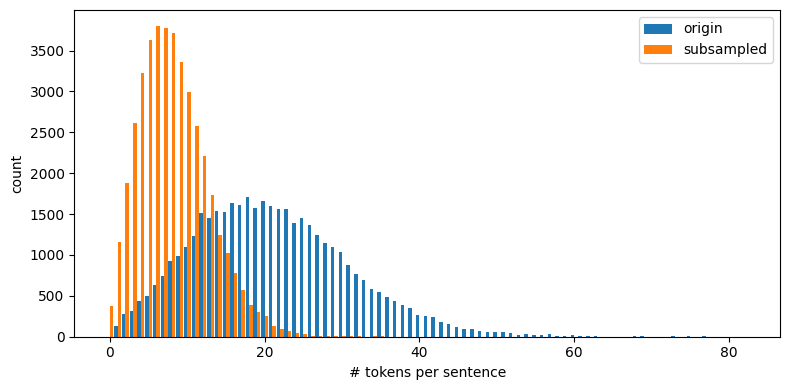

In [4]:
origin_lengths = [len(line) for line in sentences]
subsampled_lengths = [len(line) for line in subsampled]
max_length = max(origin_lengths + subsampled_lengths)
bins = range(max_length + 2)

plt.figure(figsize=(8, 4))
plt.hist(
    [origin_lengths, subsampled_lengths],
    bins=bins,
    label=['origin', 'subsampled'],
    rwidth=0.9,
    align='left'
)
plt.xlabel('# tokens per sentence')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def compare_counts(token):
    return (f'"{token}"的数量：'
            f'之前={sum([l.count(token) for l in sentences])}, '
            f'之后={sum([l.count(token) for l in subsampled])}')

compare_counts('a')

'"a"的数量：之前=21196, 之后=1298'

在下采样之后，将词元映射到它们在语料库中的索引

In [6]:
corpus = [[vocab[token] for token in line] for line in subsampled]

In [7]:
def get_centers_and_contexts(corpus, max_window_size):
    """返回跳元模型中的中心词和上下文词"""
    centers, contexts = [], []
    for line in corpus:
        # 要形成“中心词-上下文词”对，每个句子至少需要有2个词
        if len(line) < 2:
            continue
        centers += line
        for i in range(len(line)):  # 上下文窗口中间i
            window_size = random.randint(1, max_window_size)
            indices = list(range(max(0, i - window_size),
                                 min(len(line), i + 1 + window_size)))
            # 从上下文词中排除中心词
            indices.remove(i)
            contexts.append([line[idx] for idx in indices])
    return centers, contexts

In [8]:
# 最大上下文窗口大小设置为5
all_centers, all_contexts = get_centers_and_contexts(corpus, 5)


**负采样**

  

In [9]:
class RandomGenerator:
    """根据n个采样权重在{1,...,n}中随机抽取"""
    def __init__(self, sampling_weights):
        # Exclude
        self.population = list(range(1, len(sampling_weights) + 1))
        self.sampling_weights = sampling_weights
        self.candidates = []
        self.i = 0

    def draw(self):
        if self.i == len(self.candidates):
            # 缓存k个随机采样结果
            self.candidates = random.choices(
                self.population, self.sampling_weights, k=10000)
            self.i = 0
        self.i += 1
        return self.candidates[self.i - 1]

In [10]:
generator = RandomGenerator([2, 3, 4])


In [11]:
def get_negatives(all_contexts, vocab, counter, K):
    """返回负采样中的噪声词"""
    # 索引为1、2、...（索引0是词表中排除的未知标记）
    sampling_weights = [counter[vocab.idx_to_token[i]]**0.75
                        for i in range(1, len(vocab))]
    all_negatives, generator = [], RandomGenerator(sampling_weights)
    for contexts in all_contexts:
        negatives = []
        while len(negatives) < len(contexts) * K:
            neg = generator.draw()
            # 噪声词不能是上下文词
            if neg not in contexts:
                negatives.append(neg)
        all_negatives.append(negatives)
    return all_negatives

all_negatives = get_negatives(all_contexts, vocab, counter, 5)

将提取的中心词及其上下文词和采样噪声词转换成小批量的样本

In [12]:
def batchify(data):
    """返回带有负采样的跳元模型的小批量样本"""
    max_len = max(len(c) + len(n) for _, c, n in data)
    centers, contexts_negatives, masks, labels = [], [], [], []
    for center, context, negative in data:
        cur_len = len(context) + len(negative)
        centers += [center]
        contexts_negatives += \
            [context + negative + [0] * (max_len - cur_len)]
        masks += [[1] * cur_len + [0] * (max_len - cur_len)]
        labels += [[1] * len(context) + [0] * (max_len - len(context))]
    return (torch.tensor(centers).reshape((-1, 1)), torch.tensor(
        contexts_negatives), torch.tensor(masks), torch.tensor(labels))

In [13]:
def load_data_ptb(batch_size, max_window_size, num_noise_words, num_workers=0):
    """加载PTB数据集并构造带负采样的 DataLoader。"""
    sentences = read_ptb()
    vocab = Vocab(sentences, min_freq=10)
    subsampled, counter = subsample(sentences, vocab)
    corpus = [[vocab[token] for token in line] for line in subsampled]
    all_centers, all_contexts = get_centers_and_contexts(
        corpus, max_window_size)
    all_negatives = get_negatives(
        all_contexts, vocab, counter, num_noise_words)

    class PTBDataset(torch.utils.data.Dataset):
        def __init__(self, centers, contexts, negatives):
            if not len(centers) == len(contexts) == len(negatives):
                raise ValueError("centers, contexts and negatives must have equal lengths")
            self.centers = centers
            self.contexts = contexts
            self.negatives = negatives

        def __getitem__(self, index):
            return (self.centers[index], self.contexts[index],
                    self.negatives[index])

        def __len__(self):
            return len(self.centers)

    dataset = PTBDataset(all_centers, all_contexts, all_negatives)
    data_iter = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=batchify,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available())
    return data_iter, vocab

训练 word2vec 模型

In [14]:
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)

In [15]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred

In [16]:
class SigmoidBCELoss(nn.Module):
    # 带掩码的二元交叉熵损失
    def __init__(self):
        super().__init__()

    def forward(self, inputs, target, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, target, weight=mask, reduction="none")
        return out.mean(dim=1)

loss = SigmoidBCELoss()

In [17]:
def sigmd(x):
    return -math.log(1 / (1 + math.exp(-x)))


In [18]:
embed_size = 100
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size))

In [19]:
def train(net, data_iter, lr, num_epochs, device=None):
    """训练 skip-gram 模型，并返回每个 epoch 的平均损失。"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def init_weights(module):
        if isinstance(module, nn.Embedding):
            nn.init.xavier_uniform_(module.weight)

    net.apply(init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    epoch_losses = []

    for epoch in range(num_epochs):
        net.train()
        epoch_loss = 0.0
        epoch_examples = 0
        start_time = time.perf_counter()

        for center, context_negative, mask, label in data_iter:
            center = center.to(device, non_blocking=True)
            context_negative = context_negative.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = skip_gram(center, context_negative, net[0], net[1])
            batch_loss = loss(
                pred.reshape(label.shape).float(),
                label.float(),
                mask)
            batch_loss = batch_loss / mask.sum(dim=1) * mask.shape[1]
            batch_loss.sum().backward()
            optimizer.step()

            epoch_loss += batch_loss.detach().sum().item()
            epoch_examples += batch_loss.numel()

        average_loss = epoch_loss / max(epoch_examples, 1)
        epoch_losses.append(average_loss)
        elapsed = time.perf_counter() - start_time
        print(
            f"epoch {epoch + 1}/{num_epochs}, "
            f"loss {average_loss:.3f}, "
            f"{epoch_examples / max(elapsed, 1e-12):.1f} batches/sec")

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, num_epochs + 1), epoch_losses, marker="o")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.xticks(range(1, num_epochs + 1))
    plt.tight_layout()
    plt.show()
    return epoch_losses

epoch 1/20, loss 0.480, 41372.5 batches/sec
epoch 2/20, loss 0.426, 44953.4 batches/sec
epoch 3/20, loss 0.404, 44884.7 batches/sec
epoch 4/20, loss 0.380, 42670.3 batches/sec
epoch 5/20, loss 0.360, 43985.7 batches/sec
epoch 6/20, loss 0.343, 39417.1 batches/sec
epoch 7/20, loss 0.331, 42262.6 batches/sec
epoch 8/20, loss 0.321, 42913.9 batches/sec
epoch 9/20, loss 0.313, 41001.2 batches/sec
epoch 10/20, loss 0.307, 43080.6 batches/sec
epoch 11/20, loss 0.302, 42343.0 batches/sec
epoch 12/20, loss 0.298, 44469.4 batches/sec
epoch 13/20, loss 0.294, 44499.1 batches/sec
epoch 14/20, loss 0.291, 42534.5 batches/sec
epoch 15/20, loss 0.288, 41806.8 batches/sec
epoch 16/20, loss 0.285, 40389.0 batches/sec
epoch 17/20, loss 0.283, 39917.7 batches/sec
epoch 18/20, loss 0.280, 42517.6 batches/sec
epoch 19/20, loss 0.279, 43499.7 batches/sec
epoch 20/20, loss 0.277, 41391.1 batches/sec


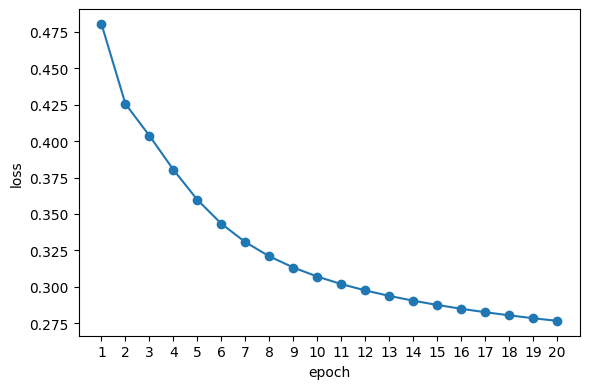

[0.48039264675952903,
 0.4255033363353582,
 0.40370891839706247,
 0.38036326441615864,
 0.3597157486833123,
 0.34330434023688,
 0.3306977808622476,
 0.32096703014423705,
 0.31329102903037953,
 0.30708195696631124,
 0.3019455160614012,
 0.2975837954259417,
 0.2938320349416081,
 0.2905403060251273,
 0.2876296186082713,
 0.28500345219895146,
 0.2826522733008006,
 0.280495657314537,
 0.278523659662612,
 0.276712076822294]

In [21]:
batch_size = 512
data_iter, vocab = load_data_ptb(
    batch_size=batch_size,
    max_window_size=5,
    num_noise_words=5)

lr, num_epochs = 0.002, 20
train(net, data_iter, lr, num_epochs)

In [22]:
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.data
    x = W[vocab[query_token]]
    # 计算余弦相似性。增加1e-9以获得数值稳定性
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) *
                                      torch.sum(x * x) + 1e-9)
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype('int32')
    for i in topk[1:]:  # 删除输入词
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')
        

In [24]:
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.detach()
    query_index = vocab[query_token]

    if query_index == vocab.unk:
        raise ValueError(f'词元 "{query_token}" 不在词表中')

    x = W[query_index]
    cos = torch.mv(W, x) / (
        torch.sqrt(torch.sum(W * W, dim=1) * torch.sum(x * x) + 1e-9)
    )

    cos[query_index] = -float('inf')
    topk = torch.topk(cos, k=min(k, len(vocab) - 1)).indices

    for i in topk.cpu().tolist():
        print(f'cosine sim={cos[i].item():.3f}: {vocab.idx_to_token[i]}')

In [26]:
get_similar_tokens('chip', 3, net[0])

cosine sim=0.601: microprocessor
cosine sim=0.574: intel
cosine sim=0.472: bugs
